# Phase D pooled-ML study: machinery, evidence, and bounded decision

**Owner-review status (audit v2, 2026-09-02)**

- Scientific verdict: **STOP — VERIFIED**
- Accepted predictions: **preserved; not regenerated**
- Execution-integrity claim: **NOT FULLY PROVEN**
- Phase D3 authorized: **NO**
- Portfolio/backtest work authorized: **NO**

This notebook is an executable explanation of the accepted Phase D evidence. It reads only
sealed artifacts and the versioned audit-v2 publication. It does not fit a model, select a
model, move a threshold, attach a new label, or write beneath the canonical data root.

The important distinction is deliberate: the negative predictive result is strong enough to
preserve `STOP`, while one historical execution detail—literal block-by-block admission of
locked labels—cannot be proven retroactively from the accepted v4 trace.

## How to read the study

Phase D asked a narrow question: does a richer pooled feature set provide enough incremental
ranking information and sufficiently favorable opportunity-tail behavior to justify more
research? The frozen design required the rich model to clear every fixed conventional
comparator, not merely the comparator it happened to beat.

The evidence arrives in a one-way sequence:

1. **D0** freezes cells, chronology, metrics, thresholds, and stop/continue rules.
2. **D1** builds label-blind structural inputs and exact point-in-time walk-forward boundaries.
3. **D2 Stage 1** fits pooled models and seals predictions without evaluation metrics.
4. **D2 Stage 2A** selects one conventional and one rich model using 2023 only.
5. **D2 Stage 2B** evaluates 2024 development confirmation.
6. **D2 Stage 2C** evaluates the locked 2025–2026H1 population.
7. **Finalization and reproduction** apply the mechanical verdict and reproduce logical hashes.
8. **Audit v2** preserves all accepted artifacts, independently rechecks decisive negative
   anchors, adds missing session concentration, and qualifies audit coverage.

In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from matplotlib.patches import FancyBboxPatch

%matplotlib inline

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (10, 5.5),
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "font.size": 10,
})

REPO_ROOT = Path(os.environ.get("ATS_REPO_ROOT", r"D:\Stock\ATS"))
DATA_ROOT = Path(os.environ.get("ATS_DATA_ROOT", r"D:\Stock\data\ATS"))
PREDICTION_DIR = Path(os.environ.get(
    "ATS_PHASE_D2_PREDICTION_RUN",
    DATA_ROOT / "phase_d_ml" / "prediction_runs" / "phase-d2-predictions-20260902-v4",
))
EVALUATION_ROOT = Path(os.environ.get(
    "ATS_PHASE_D2_EVALUATION_RUN",
    DATA_ROOT / "phase_d_ml" / "evaluation_runs" / "phase-d2-evaluation-20260902-v6",
))
REPRODUCTION_ROOT = Path(os.environ.get(
    "ATS_PHASE_D2_REPRODUCTION_RUN",
    DATA_ROOT / "phase_d_ml" / "reproductions" / "evaluation_runs"
    / "phase-d2-evaluation-20260902-v6-reproduction",
))
AUDIT_DIR = EVALUATION_ROOT / "audit-v2"
REPRODUCTION_AUDIT_DIR = REPRODUCTION_ROOT / "audit-v2"

required = [
    REPO_ROOT / "RESEARCH" / "PHASE_D2_AUDIT_REPAIR_FREEZE.md",
    PREDICTION_DIR / "manifest.json",
    EVALUATION_ROOT / "stage2a" / "selection.json",
    EVALUATION_ROOT / "stage2b" / "metrics.json",
    EVALUATION_ROOT / "stage2c" / "metrics.json",
    EVALUATION_ROOT / "final" / "gate_matrix.json",
    EVALUATION_ROOT / "final" / "verdict.json",
    AUDIT_DIR / "audit.json",
    REPRODUCTION_AUDIT_DIR / "audit.json",
]
missing = [str(path) for path in required if not path.is_file()]
assert not missing, f"Missing frozen Phase D evidence: {missing}"

def read_json(path: Path) -> dict:
    return json.loads(path.read_text(encoding="utf-8"))

def canonical_hash(value: object) -> str:
    return hashlib.sha256(
        json.dumps(value, sort_keys=True, separators=(",", ":"), allow_nan=False).encode()
    ).hexdigest()

def file_hash(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

print(f"Repository: {REPO_ROOT}")
print(f"Prediction publication: {PREDICTION_DIR.name}")
print(f"Evaluation publication: {EVALUATION_ROOT.name}")
print("Canonical data writes: disabled by notebook design")

Repository: D:\Stock\ATS
Prediction publication: phase-d2-predictions-20260902-v4
Evaluation publication: phase-d2-evaluation-20260902-v6
Canonical data writes: disabled by notebook design


In [2]:
prediction_manifest = read_json(PREDICTION_DIR / "manifest.json")
selection = read_json(EVALUATION_ROOT / "stage2a" / "selection.json")
development = read_json(EVALUATION_ROOT / "stage2b" / "metrics.json")
locked = read_json(EVALUATION_ROOT / "stage2c" / "metrics.json")
diagnostics = read_json(EVALUATION_ROOT / "stage2c" / "diagnostics.json")
monitoring = read_json(EVALUATION_ROOT / "stage2c" / "monitoring.json")
gate_matrix = read_json(EVALUATION_ROOT / "final" / "gate_matrix.json")
historical_verdict = read_json(EVALUATION_ROOT / "final" / "verdict.json")
audit = read_json(AUDIT_DIR / "audit.json")
reproduction_audit = read_json(REPRODUCTION_AUDIT_DIR / "audit.json")

def validate_audit_publication(root: Path) -> dict:
    assert sorted(path.name for path in root.iterdir()) == ["audit.json", "manifest.json"]
    evidence = read_json(root / "audit.json")
    manifest = read_json(root / "manifest.json")
    item = manifest["files"]["audit.json"]
    assert file_hash(root / "audit.json") == item["sha256"]
    assert (root / "audit.json").stat().st_size == item["bytes"]
    assert canonical_hash(evidence) == manifest["package_logical_hash"]
    assert canonical_hash(evidence["scientific_payload"]) == evidence["scientific_logical_hash"]
    return evidence

validate_audit_publication(AUDIT_DIR)
validate_audit_publication(REPRODUCTION_AUDIT_DIR)
assert audit["scientific_logical_hash"] == reproduction_audit["scientific_logical_hash"]
assert prediction_manifest["logical_payload"]["prediction_identity"]["logical_hash"] == (
    "ad9ea68d66fde122e127d502706f8eeaea162749b6f67a38b1a68ac0c06e8466"
)
assert audit["scientific_logical_hash"] == (
    "397d66ed3c88c8e914c1a6bbdc9af7875f0d553acbd86c48dcb8d3f64eab944c"
)

status_table = pd.DataFrame([
    ("Overall audit", audit["audit_status"]),
    ("Scientific Phase D verdict", audit["scientific_stop_status"]),
    ("Execution integrity", audit["execution_integrity"]["status"]),
    ("Prediction regenerated", str(audit["prediction_regenerated"]).upper()),
    ("Scientific choice changed", str(audit["scientific_choice_changed"]).upper()),
    ("Primary/reproduction audit science", "EXACT MATCH"),
    ("D3 authorized", audit["scientific_payload"]["d3_execution_authorized"]),
    ("Portfolio/backtest authorized", audit["scientific_payload"]["portfolio_backtest_work_authorized"]),
], columns=["Question", "Answer"])
display(status_table)

,Question,Answer
0,Overall audit,PASS WITH EXECUTION-INTEGRITY QUALIFICATION
1,Scientific Phase D verdict,STOP — VERIFIED
2,Execution integrity,NOT FULLY PROVEN
3,Prediction regenerated,FALSE
4,Scientific choice changed,FALSE
5,Primary/reproduction audit science,EXACT MATCH
6,D3 authorized,NO
7,Portfolio/backtest authorized,NO


## The machinery: strict information flow, pooled cross-section

A row is a security observed at a decision session. Features must be known by the 08:45
decision time. The primary target is the absolute split-adjusted open-to-open return over 20
trading sessions. Five cells share the same score population: conventional ridge and
LightGBM, rich ridge and LightGBM, plus a diagnostic rich LightGBM without market-state
features.

Every refit uses pooled security-session rows from a trailing chronological window. Exact
label endpoint timestamps—not a fixed row subtraction—purge observations whose target was
not yet knowable. Inner chronological scores set a strict `score > threshold` opportunity
rule; the final refit then scores the next half-year block. Selection and evaluation remain
separate publications so later outcomes cannot alter earlier choices.

The accepted models were not shown to consume an immature label. The narrower unresolved
audit issue is access sequencing: accepted Stage 1 loaded the union of eventual training
labels before generating its first block. Future code now admits only the sessions required
by the next outer block and fails closed on wrong order, but that new trace cannot be imputed
to the historical v4 run.

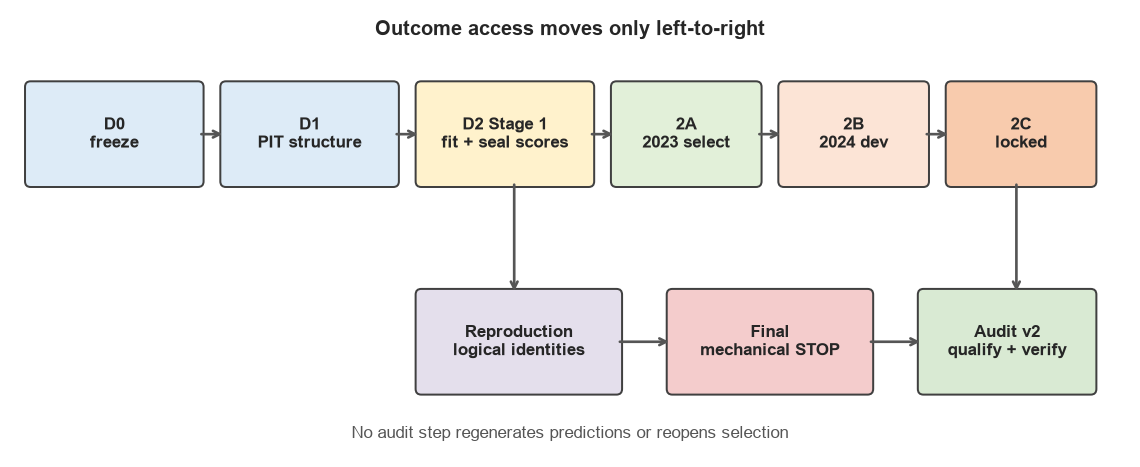

In [3]:
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4.7)
ax.axis("off")

boxes = [
    (0.2, 2.9, 1.8, 1.0, "D0\nfreeze", "#ddebf7"),
    (2.3, 2.9, 1.8, 1.0, "D1\nPIT structure", "#ddebf7"),
    (4.4, 2.9, 1.8, 1.0, "D2 Stage 1\nfit + seal scores", "#fff2cc"),
    (6.5, 2.9, 1.5, 1.0, "2A\n2023 select", "#e2f0d9"),
    (8.3, 2.9, 1.5, 1.0, "2B\n2024 dev", "#fce4d6"),
    (10.1, 2.9, 1.5, 1.0, "2C\nlocked", "#f8cbad"),
    (4.4, 0.7, 2.1, 1.0, "Reproduction\nlogical identities", "#e4dfec"),
    (7.1, 0.7, 2.1, 1.0, "Final\nmechanical STOP", "#f4cccc"),
    (9.8, 0.7, 1.8, 1.0, "Audit v2\nqualify + verify", "#d9ead3"),
]
for x, y, width, height, label, color in boxes:
    patch = FancyBboxPatch(
        (x, y), width, height, boxstyle="round,pad=0.06",
        linewidth=1.2, edgecolor="#404040", facecolor=color,
    )
    ax.add_patch(patch)
    ax.text(x + width / 2, y + height / 2, label, ha="center", va="center", weight="bold")

def arrow(x1, y1, x2, y2):
    ax.annotate("", xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle="->", lw=1.6, color="#555555"))

for x1, x2 in [(2.0, 2.3), (4.1, 4.4), (6.2, 6.5), (8.0, 8.3), (9.8, 10.1)]:
    arrow(x1, 3.4, x2, 3.4)
arrow(5.4, 2.9, 5.4, 1.7)
arrow(6.5, 1.2, 7.1, 1.2)
arrow(9.2, 1.2, 9.8, 1.2)
arrow(10.8, 2.9, 10.8, 1.7)

ax.text(6.0, 4.45, "Outcome access moves only left-to-right", ha="center", fontsize=12, weight="bold")
ax.text(6.0, 0.18, "No audit step regenerates predictions or reopens selection", ha="center", color="#555555")
plt.show()

## Chronology is part of the estimand

The halves below are not interchangeable random folds. The 2023 blocks choose model family
within conventional and rich representations. The 2024 blocks confirm development behavior.
Only after those choices are sealed are the 2025–2026H1 locked outcomes evaluated. The
partial 2026H2 monitoring block reports score frequency only because its outcomes are right
censored and nongating.

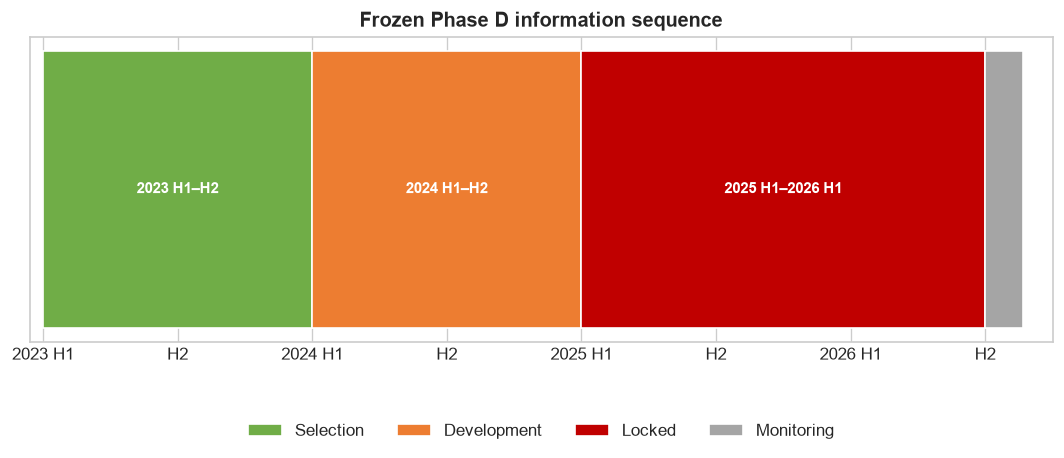

Partial monitoring: 35 sessions; outcomes loaded=False; nongating=True


In [4]:
windows = pd.DataFrame([
    (2023.00, 2024.00, "Selection", "2023 H1–H2", "#70ad47"),
    (2024.00, 2025.00, "Development", "2024 H1–H2", "#ed7d31"),
    (2025.00, 2026.50, "Locked", "2025 H1–2026 H1", "#c00000"),
    (2026.50, 2026.64, "Monitoring", "", "#a5a5a5"),
], columns=["start", "end", "role", "label", "color"])
fig, ax = plt.subplots(figsize=(11, 3.3))
for idx, row in windows.iterrows():
    ax.barh(0, row.end - row.start, left=row.start, height=0.48, color=row.color,
            edgecolor="white", label=row.role)
    ax.text((row.start + row.end) / 2, 0, row.label, ha="center", va="center",
            color="white", weight="bold", fontsize=9)
ax.set_xlim(2022.95, 2026.75)
ax.set_yticks([])
ax.set_xticks([2023, 2023.5, 2024, 2024.5, 2025, 2025.5, 2026, 2026.5])
ax.set_xticklabels(["2023 H1", "H2", "2024 H1", "H2", "2025 H1", "H2", "2026 H1", "H2"])
ax.set_title("Frozen Phase D information sequence")
ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.22), frameon=False)
plt.show()
print(
    f"Partial monitoring: {monitoring['scored_sessions']} sessions; "
    f"outcomes loaded={monitoring['outcomes_loaded']}; nongating={monitoring['nongating']}"
)

## Stage 2A: model-family selection, not rich-vs-conventional selection

The 2023 statistic is equal-session-weighted Spearman rank IC. LightGBM won within both the
conventional and rich representations, so `C_LIGHTGBM` and `RICH_LIGHTGBM` were frozen before
development evaluation. The strong 2023 rich value is not itself evidence to continue: D0
required confirmation on later populations and comparison against **each** conventional model.

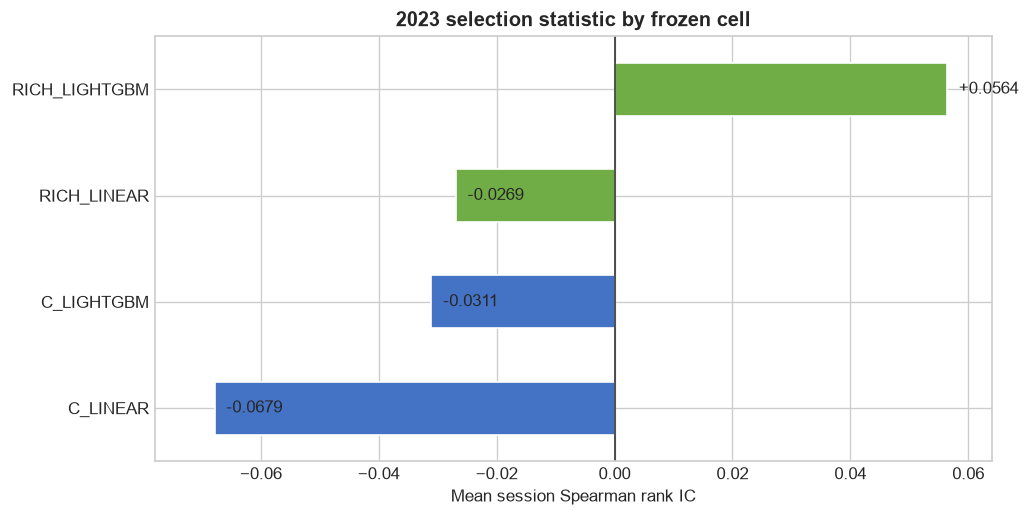

,Representation,Selected family
0,Conventional,C_LIGHTGBM
1,Rich,RICH_LIGHTGBM


In [5]:
selection_series = pd.Series(selection["cell_statistics"], name="mean_session_rank_IC").sort_values()
colors = ["#4472c4" if name.startswith("C_") else "#70ad47" for name in selection_series.index]
ax = selection_series.plot.barh(color=colors, edgecolor="white", figsize=(9, 4.6))
ax.axvline(0, color="#333333", lw=1)
for patch, value in zip(ax.patches, selection_series.values):
    ax.text(value + 0.002, patch.get_y() + patch.get_height()/2,
            f"{value:+.4f}", va="center", ha="left")
ax.set_xlim(-0.078, 0.064)
ax.set_title("2023 selection statistic by frozen cell")
ax.set_xlabel("Mean session Spearman rank IC")
plt.show()
display(pd.DataFrame([
    ("Conventional", selection["conventional"]["selected"]),
    ("Rich", selection["rich"]["selected"]),
], columns=["Representation", "Selected family"]))

## The decisive rank-information failure

The frozen requirement was a mean rich-minus-conventional IC delta of at least `+0.010`
against **each** conventional comparator. Rich LightGBM beat conventional LightGBM on average
in both later populations, but it lost to conventional ridge. Because every fixed comparator
had to pass, identity or row order cannot rescue the result by changing which baseline is
emphasized.

Audit v2 independently recomputed these means from sealed predictions and outcomes. The
primary and reproduction audit payloads match exactly.

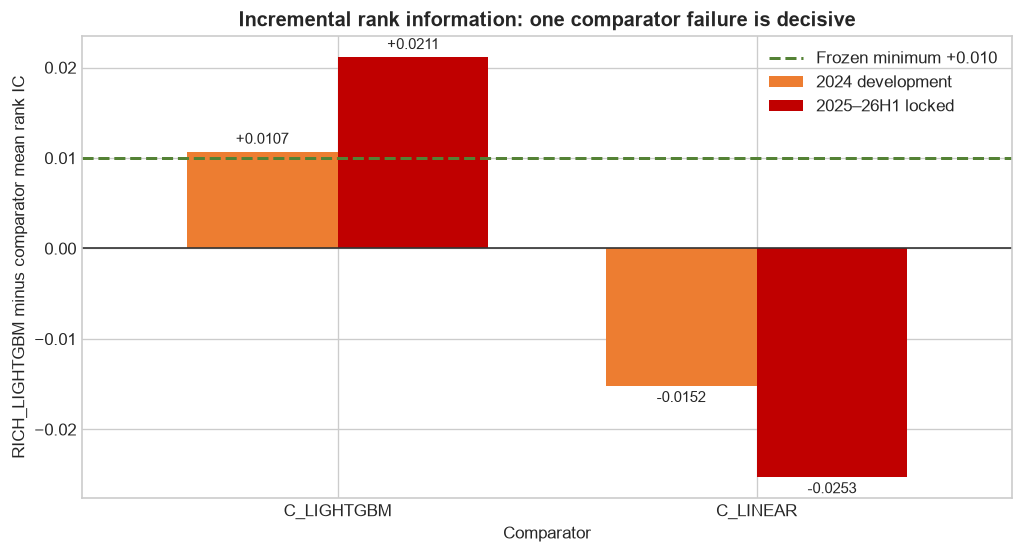

,Population,Comparator,Delta IC
0,2024 development,C_LIGHTGBM,0.010675
1,2024 development,C_LINEAR,-0.015205
2,2025–26H1 locked,C_LIGHTGBM,0.021144
3,2025–26H1 locked,C_LINEAR,-0.025285


In [6]:
negative = audit["scientific_payload"]["negative_result"]
delta_rows = []
for stage, label in [("stage2b", "2024 development"), ("stage2c", "2025–26H1 locked")]:
    for comparator, value in negative["mean_delta_ic"][stage].items():
        delta_rows.append((label, comparator, value))
delta_df = pd.DataFrame(delta_rows, columns=["Population", "Comparator", "Delta IC"])
pivot = delta_df.pivot(index="Comparator", columns="Population", values="Delta IC")
ax = pivot.plot.bar(figsize=(10, 5), color=["#ed7d31", "#c00000"], width=0.72)
ax.axhline(0.010, color="#548235", linestyle="--", lw=1.8, label="Frozen minimum +0.010")
ax.axhline(0, color="#333333", lw=1)
ax.set_ylabel("RICH_LIGHTGBM minus comparator mean rank IC")
ax.set_title("Incremental rank information: one comparator failure is decisive")
ax.legend(frameon=False)
for container in ax.containers[:2]:
    ax.bar_label(container, fmt="%+.4f", padding=3, fontsize=9)
plt.xticks(rotation=0)
plt.show()
display(delta_df)

## Opportunity tails did not provide a rescue

A model can rank well overall yet fail where its threshold says an opportunity exists. The
locked rich episode anchors were therefore compared with eligible rows and with conventional
candidates matched to the rich opportunity frequency. Against the two conventional
comparators, the locked rich mean return difference was negative: about **−0.65 percentage
points versus conventional ridge** and **−1.29 points versus conventional LightGBM**. Relevant
lower confidence bounds were also below zero in the accepted primary calculation.

The rich-minus-eligible mean was positive, but the contract required all decisive comparator
gates; a favorable nongoverning contrast cannot override failures elsewhere.

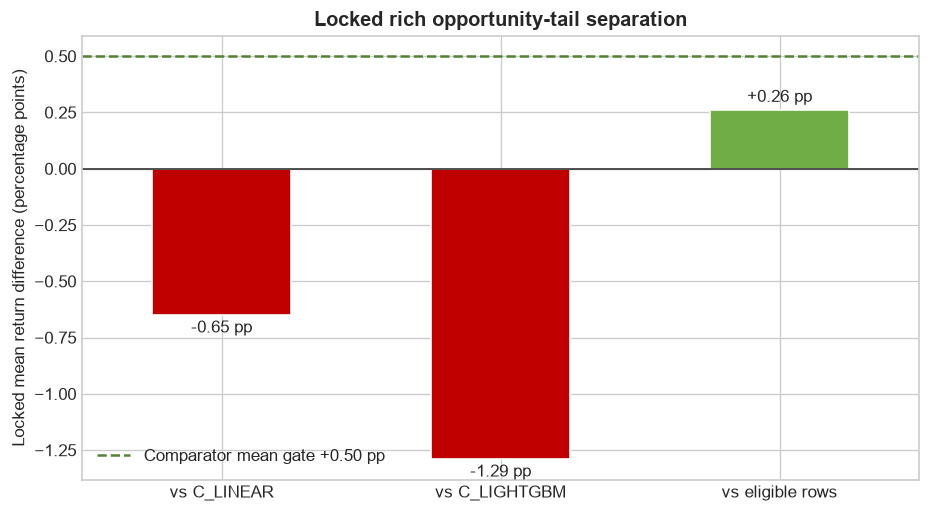

In [7]:
locked_tail = {
    "vs C_LINEAR": locked["rich_minus_conventional_mean_return"]["C_LINEAR"],
    "vs C_LIGHTGBM": locked["rich_minus_conventional_mean_return"]["C_LIGHTGBM"],
    "vs eligible rows": locked["rich_minus_eligible_mean_return"],
}
tail = pd.Series(locked_tail).mul(100)
colors = ["#c00000" if value < 0 else "#70ad47" for value in tail]
ax = tail.plot.bar(color=colors, edgecolor="white", figsize=(9, 4.8))
ax.axhline(0, color="#333333", lw=1)
ax.axhline(0.5, color="#548235", linestyle="--", label="Comparator mean gate +0.50 pp")
ax.set_ylabel("Locked mean return difference (percentage points)")
ax.set_title("Locked rich opportunity-tail separation")
ax.legend(frameon=False)
ax.bar_label(ax.containers[0], fmt="%+.2f pp", padding=3)
plt.xticks(rotation=0)
plt.show()

## Threshold behavior changed sharply over time

Opportunity frequency is part of the frozen evidence, not an implementation footnote. The
model was very active in 2024H1, then became highly abstaining. In 2025H2 and 2026H1 fewer
than 10% of sessions had a rich opportunity, while 2024H1 also exceeded candidate-row and
per-session crowding limits. This instability agrees with the stop decision; it is not used
to invent a new threshold after seeing outcomes.

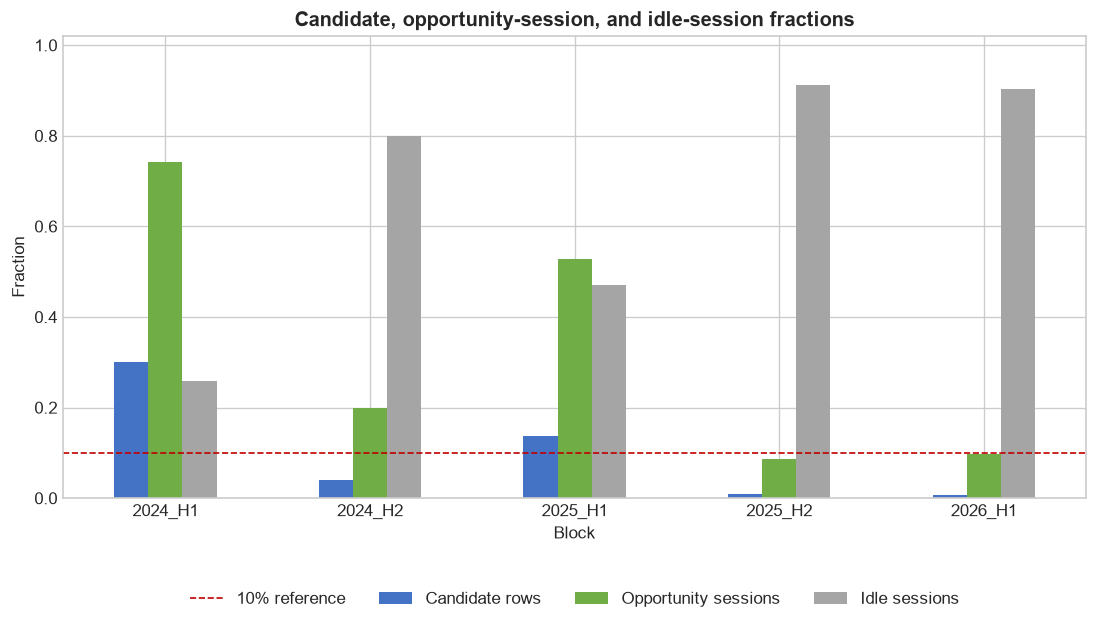

,Candidate rows,Opportunity sessions,Idle sessions
Block,,,
2024_H1,0.3007,0.7419,0.2581
2024_H2,0.0405,0.2000,0.8000
2025_H1,0.1374,0.5285,0.4715
2025_H2,0.0092,0.0873,0.9127
2026_H1,0.0073,0.0976,0.9024


In [8]:
frequency_rows = []
for metrics, prefix in [(development, "Development"), (locked, "Locked")]:
    for block, values in metrics["frequency_by_block"].items():
        frequency_rows.append({
            "Block": block.replace("DEVELOPMENT_", "").replace("LOCKED_", ""),
            "Candidate rows": values["candidate_row_fraction"],
            "Opportunity sessions": values["opportunity_session_fraction"],
            "Idle sessions": values["idle_session_fraction"],
        })
frequency_df = pd.DataFrame(frequency_rows).set_index("Block")
ax = frequency_df.plot.bar(figsize=(11, 5), color=["#4472c4", "#70ad47", "#a5a5a5"])
ax.axhline(0.10, color="#c00000", linestyle="--", lw=1, label="10% reference")
ax.set_ylabel("Fraction")
ax.set_ylim(0, 1.02)
ax.set_title("Candidate, opportunity-session, and idle-session fractions")
ax.legend(ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.17))
plt.xticks(rotation=0)
plt.show()
display(frequency_df.round(4))

## Gate matrix: broad failure, not one marginal miss

The historical final gate matrix contains 177 rows. Its execution-integrity rows are shown in
the accepted artifact as `PASS`, but audit v2 discovered that those 26 rows were originally
emitted as constants. The chart below therefore summarizes **scientific and validity rows
only**; execution integrity is handled separately from artifact-derived checks in the next
sections.

Failures span incremental rank information, opportunity tails, frequency/abstention,
chronological stability, and concentration. This breadth is why the scientific `STOP` does
not depend on resolving the historical label-access trace.

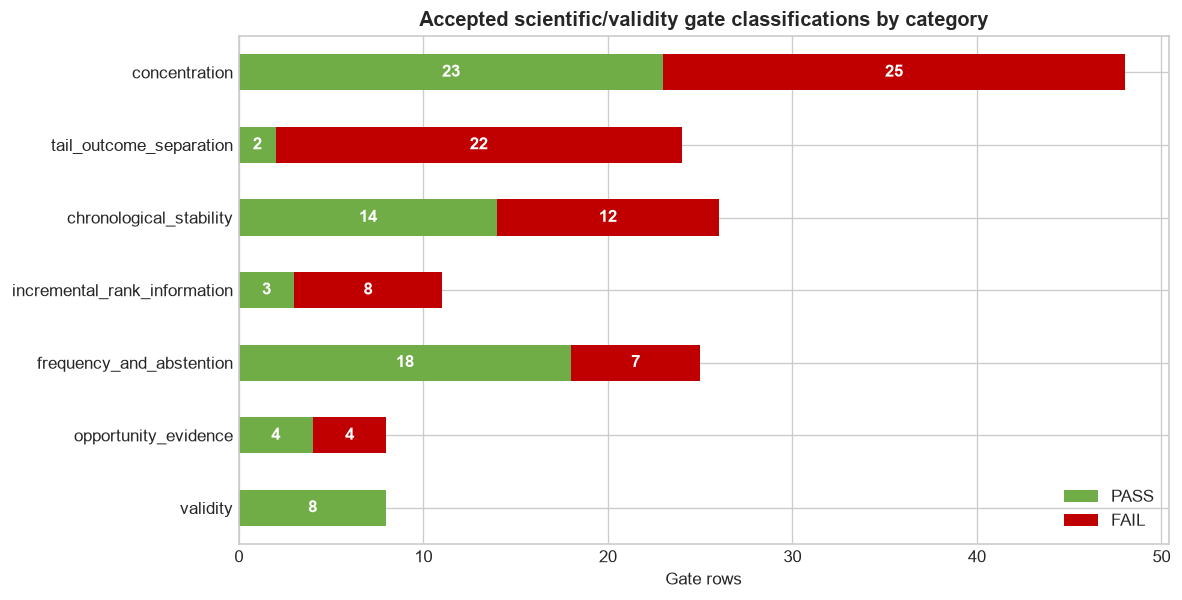

status,PASS,FAIL
category,,
validity,8,0
opportunity_evidence,4,4
frequency_and_abstention,18,7
incremental_rank_information,3,8
chronological_stability,14,12
tail_outcome_separation,2,22
concentration,23,25


Historical gate rows: 177; historical execution-integrity rows: 26


In [9]:
gates = pd.DataFrame(gate_matrix["gates"])
scientific_gates = gates.loc[~gates["category"].isin(["execution_integrity", "reproducibility"])]
gate_counts = scientific_gates.groupby(["category", "status"]).size().unstack(fill_value=0)
gate_counts = gate_counts.reindex(columns=["PASS", "FAIL"], fill_value=0).sort_values("FAIL")
ax = gate_counts.plot.barh(stacked=True, figsize=(10, 5.5), color=["#70ad47", "#c00000"])
ax.set_xlabel("Gate rows")
ax.set_ylabel("")
ax.set_title("Accepted scientific/validity gate classifications by category")
ax.legend(frameon=False)
for container in ax.containers:
    labels = [str(int(value)) if value else "" for value in container.datavalues]
    ax.bar_label(container, labels=labels, label_type="center", color="white", weight="bold")
plt.show()
display(gate_counts)
print(f"Historical gate rows: {len(gates)}; historical execution-integrity rows: "
      f"{gates['category'].eq('execution_integrity').sum()}")

## Concentration: the missing reporting dimension is now explicit

Stage 2 originally reported security concentration and chronological-quartile concentration,
but not largest-session share or session HHI. Audit v2 computes those missing dimensions from
the already sealed, outcome-evaluable rich episode anchors—no model or threshold is rerun.

Development had 198 anchors across 43 nonzero sessions; its largest single session carried
21.2% and the top five carried 56.6%. Locked evidence had 133 anchors across 28 sessions; its
largest session carried 27.1% and the top five carried 54.1%. These are reporting diagnostics
because D0 froze no session-concentration threshold. They strengthen the description of how
episodic the evidence was but cannot change `STOP`.

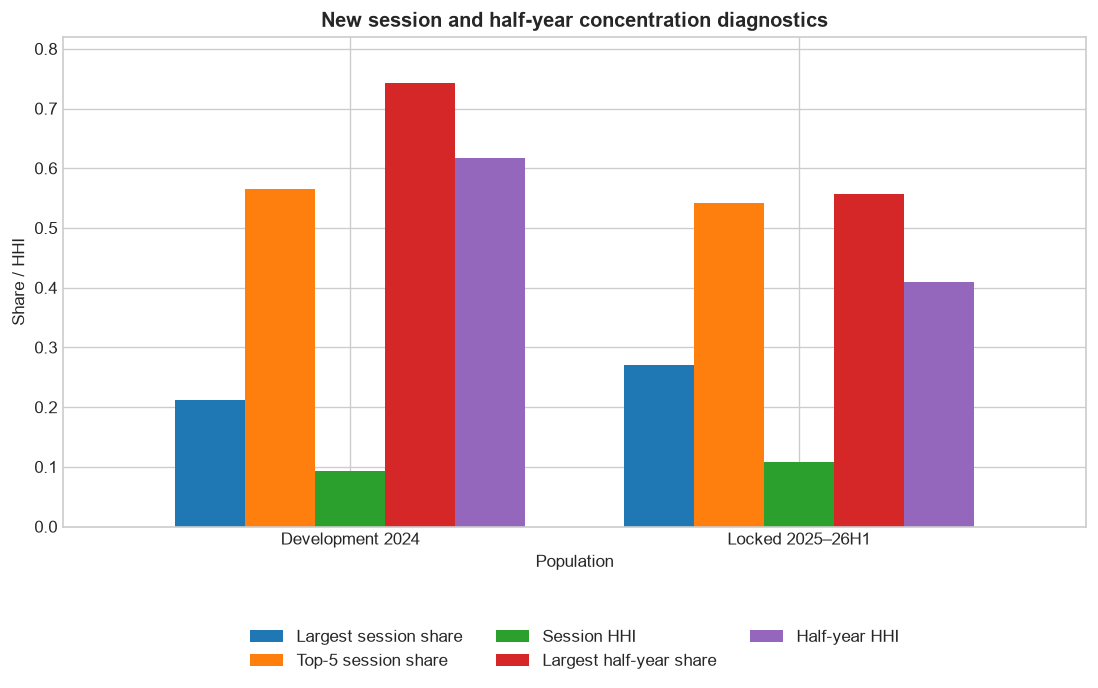

,Episodes,Nonzero sessions,Largest session share,Top-5 session share,Session HHI,Largest half-year share,Half-year HHI
Population,,,,,,,
Development 2024,198,43,0.2121,0.5657,0.0928,0.7424,0.6175
Locked 2025–26H1,133,28,0.2707,0.5414,0.1081,0.5564,0.4094


,Largest security,Top-5 securities,Security HHI,Largest chrono quartile
Population,,,,
Development 2024,0.0303,0.1263,0.0181,0.4697
Locked 2025–26H1,0.0376,0.1579,0.0212,0.4361


In [10]:
concentration = audit["scientific_payload"]["session_and_period_concentration"]
conc_rows = []
for stage, label in [("stage2b", "Development 2024"), ("stage2c", "Locked 2025–26H1")]:
    item = concentration[stage]
    conc_rows.append({
        "Population": label,
        "Episodes": item["episode_count"],
        "Nonzero sessions": item["nonzero_sessions"],
        "Largest session share": item["largest_session_episode_share"],
        "Top-5 session share": item["top5_session_episode_share"],
        "Session HHI": item["session_episode_hhi"],
        "Largest half-year share": item["largest_block_episode_share"],
        "Half-year HHI": item["block_episode_hhi"],
    })
conc_df = pd.DataFrame(conc_rows).set_index("Population")
plot_cols = [
    "Largest session share", "Top-5 session share", "Session HHI",
    "Largest half-year share", "Half-year HHI",
]
ax = conc_df[plot_cols].plot.bar(figsize=(11, 5.3), width=0.78)
ax.set_ylim(0, 0.82)
ax.set_ylabel("Share / HHI")
ax.set_title("New session and half-year concentration diagnostics")
ax.legend(ncol=3, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.18))
plt.xticks(rotation=0)
plt.show()
display(conc_df.round(4))

previously_reported = pd.DataFrame([
    ("Development 2024", development["concentration"]["largest_security_episode_share"],
     development["concentration"]["top5_security_episode_share"],
     development["concentration"]["security_episode_hhi"],
     development["concentration"]["largest_chronological_quartile_share"]),
    ("Locked 2025–26H1", locked["concentration"]["largest_security_episode_share"],
     locked["concentration"]["top5_security_episode_share"],
     locked["concentration"]["security_episode_hhi"],
     locked["concentration"]["largest_chronological_quartile_share"]),
], columns=["Population", "Largest security", "Top-5 securities", "Security HHI", "Largest chrono quartile"])
display(previously_reported.set_index("Population").round(4))

## Diagnostics stay diagnostic

Removing the market-state features improved locked mean session IC by about 0.0289, so the
market-state feature block did not explain a hidden success. Secondary 5- and 10-session
labels and the proximity subgroup are descriptive only. Feature importance and path
diagnostics were not prespecified as gates and were correctly left uncomputed or deferred.

This is a useful example of phase discipline: an interesting ablation does not authorize a
new model family, a feature redesign, or a fresh locked test after the answer is known.

In [11]:
ablation = diagnostics["market_state_ablation"]
diagnostic_table = pd.DataFrame([
    ("Market-state ablation population identical", ablation["identical_population"]),
    ("With-minus-without market-state mean IC", ablation["mean_session_ic_difference"]),
    ("Role", ablation["role"]),
    ("Feature importance", diagnostics["feature_importance"]),
    ("Forward paths", diagnostics["forward_path_diagnostics"]),
    ("Diagnostics can rescue gate", not diagnostics["diagnostics_cannot_rescue_gate"]),
], columns=["Diagnostic", "Value"])
display(diagnostic_table)
secondary = pd.DataFrame(diagnostics["secondary_labels"]).T
secondary.index.name = "Secondary label"
display(secondary.round(4))

,Diagnostic,Value
0,Market-state ablation population identical,True
1,With-minus-without market-state mean IC,-0.028911
2,Role,DIAGNOSTIC ONLY
3,Feature importance,NOT COMPUTED; optional descriptive diagnostic
4,Forward paths,DEFERRED BY CONTRACT: no frozen MFE/MAE/time/p...
5,Diagnostics can rescue gate,False


,C_LIGHTGBM,C_LINEAR,RICH_LIGHTGBM
Secondary label,,,
label__open_to_open__10,0.0104,0.0499,0.0238
label__open_to_open__5,-0.0004,0.0430,0.0242


## What audit v2 proves—and what it deliberately does not claim

Audit v2 validates every sealed input inventory, byte hash, and logical payload. It
independently recomputes 2023 selection and the decisive development/locked mean-IC anchors,
plus the evaluator's core denominators, frequencies, anchors, tails, severe outcomes, and
existing concentration summaries. It also independently adds session and half-year
concentration.

It does **not** claim a second implementation of every bootstrap interval,
leave-top-contributor result, annual gate input, or every other stored gate input. Those
remaining stored values are reclassified, not fully recomputed. That narrower claim is more
accurate than the original statement that every decisive metric and gate had been matched.

The hardened overall classifier is fail-closed. `PASS WITH EXECUTION-INTEGRITY
QUALIFICATION` is allowed only when the independent core passes, the scientific `STOP` is
independently reproduced, the accepted verdict is `STOP`, no integrity item fails, and the
sole `NOT PROVEN` item is `sequential_locked_label_admission`. Any demonstrated integrity or
independent-core failure is `FAIL`; any other insufficiency is `NOT PROVEN`.

In [12]:
coverage = audit["independent_core_evaluator"]["coverage"]
coverage_table = pd.DataFrame([
    *[("Independently recomputed", item) for item in coverage["independently_recomputed"]],
    *[("Not independently recomputed", item) for item in coverage["not_independently_recomputed"]],
], columns=["Coverage", "Item"])
display(coverage_table)

integrity = pd.DataFrame(audit["execution_integrity"]["checks"])
display(integrity[["check_id", "status", "evidence"]])
assert integrity.loc[integrity["check_id"].eq("sequential_locked_label_admission"), "status"].item() == "NOT PROVEN"
assert integrity.loc[~integrity["check_id"].eq("sequential_locked_label_admission"), "status"].eq("PASS").all()

,Coverage,Item
0,Independently recomputed,2023 within-representation model selection
1,Independently recomputed,population denominators
2,Independently recomputed,mean session IC and paired mean delta IC
3,Independently recomputed,candidate and idle frequencies
4,Independently recomputed,episode anchors
5,Independently recomputed,rich-minus-eligible and frequency-matched mean...
6,Independently recomputed,severe-outcome rate differences
7,Independently recomputed,security and chronological-quartile concentration
8,Independently recomputed,new session and half-year block concentration
9,Not independently recomputed,bootstrap intervals and defined-replicate frac...


,check_id,status,evidence
0,pit_membership_and_information_timing,PASS,sealed mask timestamps
1,official_denominator_60,PASS,sealed mask rows and scored/excluded counts
2,exact_label_anchors_and_availability,PASS,"sealed outcome states, endpoints, and values"
3,endpoint_derived_purge,PASS,all retained fit endpoint proofs
4,fold_local_preprocessing,PASS,all fit/calibration records
5,identity_predictors_absent,PASS,all sealed fit feature allowlists
6,identity_neutral_ties,PASS,strict candidates and frozen frequency-match t...
7,common_score_and_outcome_populations,PASS,sealed cell/mask/outcome semantic keys
8,ablation_population_identical,PASS,sealed ablation semantic keys
9,actual_minimums,PASS,retained counts versus frozen minima


## Owner decision

The accepted predictions and the negative scientific result stand. The rich model failed a
prespecified incremental-IC comparison against conventional ridge in both development and
locked evidence, and its locked frequency-matched opportunity tail was worse than both
conventional comparators. Primary and reproduction audit-v2 scientific payloads match
exactly.

**Disposition:**

- **Phase D research verdict: STOP — VERIFIED**
- **D2 execution integrity: NOT FULLY PROVEN** because the historical v4 run lacks a literal
  sequential label-admission trace
- **D3: not authorized**
- **Portfolio/backtest work: not authorized**
- No new feature, threshold, model, subgroup, optimization, or deployment branch follows from
  this notebook

This conclusion is deliberately narrow: the frozen Phase D representation, model-family,
threshold, and evaluation contract stopped. It does **not** empirically reject every
conceivable machine-learning approach. Untested model families and representations remain
deferred, and this result does not authorize searching them.

The forward runtime has been repaired so any future Stage 1 execution must admit labels in
exact outer-block order and must derive integrity gates from retained evidence. That repair
improves future auditability; it does not rewrite history or turn the accepted v4 execution
claim into a proof.

In [13]:
assert audit["scientific_stop_status"] == "STOP — VERIFIED"
assert audit["audit_status"] == "PASS WITH EXECUTION-INTEGRITY QUALIFICATION"
assert audit["execution_integrity"]["status"] == "NOT FULLY PROVEN"
assert audit["prediction_regenerated"] is False
assert audit["scientific_choice_changed"] is False
assert historical_verdict["frozen_phase_d_research_verdict"] == "STOP"
assert audit["scientific_payload"]["d3_execution_authorized"] == "NO"
assert audit["scientific_payload"]["portfolio_backtest_work_authorized"] == "NO"

display(Markdown(
    "### Executable conclusion" + chr(10) * 2
    + f"**{audit['scientific_stop_status']}**  " + chr(10)
    + f"Execution integrity: **{audit['execution_integrity']['status']}**  " + chr(10)
    + f"Audit scientific identity: `{audit['scientific_logical_hash']}`"
))

### Executable conclusion

**STOP — VERIFIED**  
Execution integrity: **NOT FULLY PROVEN**  
Audit scientific identity: `397d66ed3c88c8e914c1a6bbdc9af7875f0d553acbd86c48dcb8d3f64eab944c`